# License Plate Detection & Recognition


---

## Overview

This notebook implements a classical pipeline for automatic license plate detection and character recognition. The system processes images of vehicles to:

1. Detect license plate regions.
2. Segment individual characters.
3. Recognize text using classical OCR techniques.

**Constraints:** No deep learning or pretrained neural networks - only OpenCV, NumPy, and classical ML methods.

---

In [1]:
import math
import os
import numpy as np

import cv2 as cv
import matplotlib.pyplot as plt

In [2]:
images_dir = './images/'
templates_dir = './char_templates/'

In [3]:
char_h = 40
char_w = 40

In [4]:
images_paths = []

for image in os.listdir(images_dir):
    images_paths.append(os.path.join(images_dir, image))

print(images_paths)

['./images/1.png', './images/2.png', './images/3.png', './images/4.png', './images/5.jpg', './images/6.jpg', './images/7.jpg', './images/8.jpg', './images/9.jpg']


In [5]:
def show_images(images, cols=2, width=5, height=5, titles=None, main_title=None):
    imgs_count = len(images)
    if cols > imgs_count:
        cols = imgs_count

    rows = math.ceil(imgs_count / cols)

    figsize = (width * cols, height * rows)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    if hasattr(axes, 'flatten'):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, ax in enumerate(axes):
        if i < imgs_count:
            if len(images[i].shape) == 2:
                ax.imshow(images[i], cmap='gray')
            else:
                ax.imshow(images[i])

            # Add title if provided
            if titles is not None and i < len(titles):
                ax.set_title(titles[i], fontsize=10, pad=5)

        ax.axis('off')

    # Add main title if provided
    if main_title is not None:
        fig.suptitle(main_title, fontsize=14, fontweight='bold', y=0.98)

    plt.tight_layout()
    plt.show()

In [6]:
images = [cv.imread(image, cv.IMREAD_COLOR_RGB) for image in images_paths]

#### Below given test images are displayed in a grid layout for comparison and analysis.

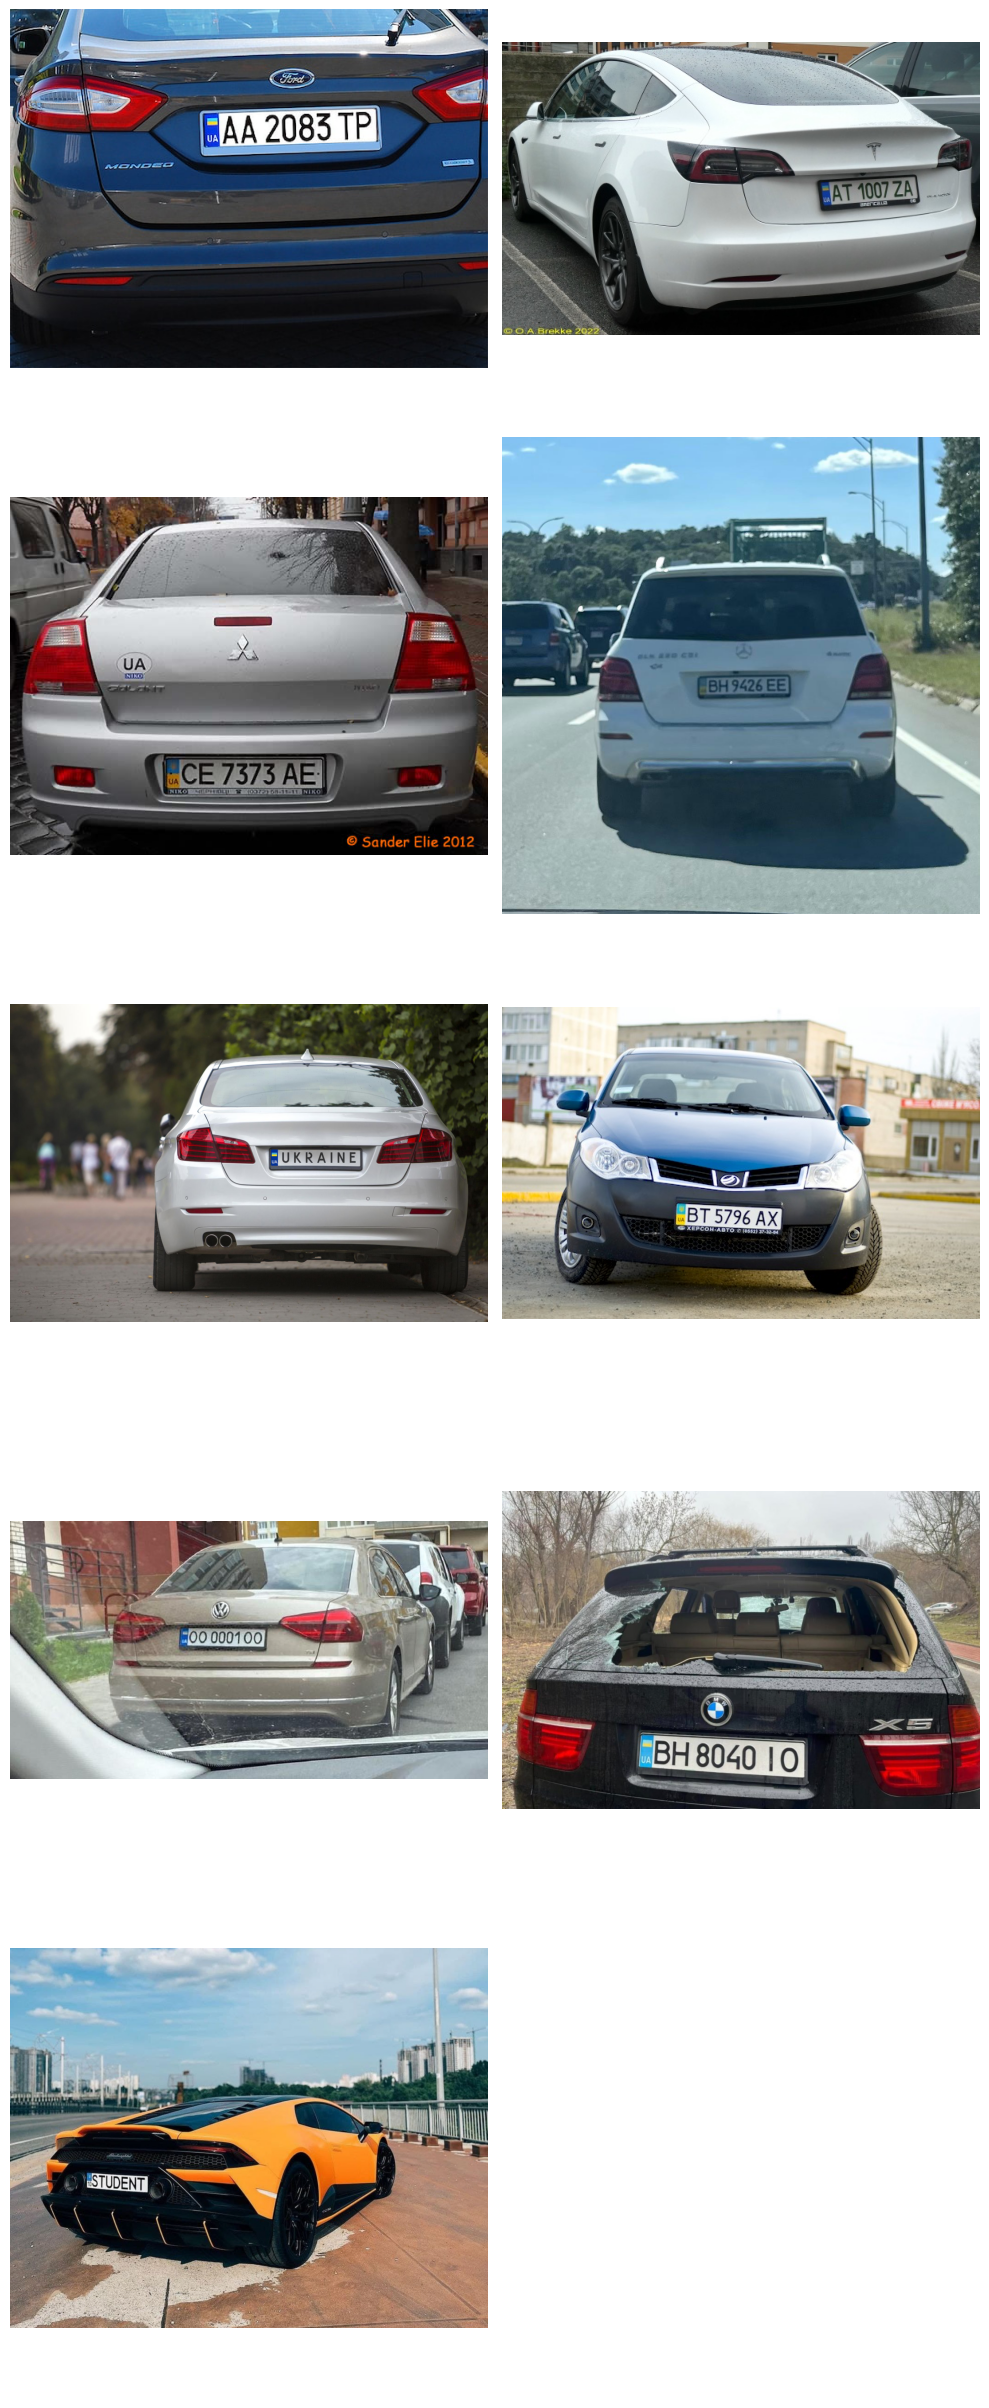

In [7]:
show_images(images, cols=2)

#### Ordering corner points for perspective transformation (top-left, top-right, bottom-right, bottom-left).

In [8]:
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

#### Computing homography matrix to correct plate perspective and extract rectangular ROI.

In [9]:
def get_perspective(pts):
    rect = order_points(pts)

    (tl, tr, br, bl) = rect
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    M = cv.getPerspectiveTransform(rect, dst)
    return M, maxWidth, maxHeight


#### Extracting individual characters from the license plate region.

Detecting character contours and filter based on:
- Height constraints (50% to 95% of plate height)
- Aspect ratio (must be taller than wide)
- Median height alignment (within 10% tolerance)

In [10]:
def find_characters(plate):
    plate_h = 60

    height_tolerance = 0.1

    p_h, p_w, _ = plate.shape
    if p_h == 0: return None
    plate = cv.resize(plate, (int(p_w / p_h * plate_h), plate_h), interpolation=cv.INTER_AREA)
    p_h, p_w, _ = plate.shape

    min_char_height = p_h * 0.5
    max_char_height = p_h * 0.95


    gray = cv.cvtColor(plate, cv.COLOR_RGB2GRAY)
    _, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)


    char_contours, _ = cv.findContours(thresh.copy(), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    char_contours = sorted(char_contours, key=lambda c: cv.boundingRect(c)[0])
    potential_chars = []


    for contour in char_contours:
        x, y, w, h = cv.boundingRect(contour)
        aspect = w / float(h)
        if min_char_height <= h <= max_char_height and aspect < 1.0:
            potential_chars.append(contour)


    chars = []

    if len(potential_chars) > 3:
        heights = [cv.boundingRect(c)[3] for c in potential_chars]

        median_height = np.median(heights)

        min_accepted_h = median_height * (1 - height_tolerance)
        max_accepted_h = median_height * (1 + height_tolerance)

        for contour in potential_chars:
            x, y, w, h = cv.boundingRect(contour)
            if min_accepted_h <= h <= max_accepted_h:
                chars.append(contour)

    if 4 > len(chars) or len(chars) > 10:
        return None

    char_rects = []

    for char_contour in chars:
        x, y, w, h = cv.boundingRect(char_contour)
        char_rects.append(
            cv.resize(thresh[y:y + h, x:x + w], (int(w / h * char_h), char_h), interpolation=cv.INTER_CUBIC)
        )

    final_rects = []

    for rect in char_rects:
        h, w = rect.shape
        canvas = np.zeros((char_w, char_h), dtype=np.uint8)

        paste_y = (char_h - h) // 2
        paste_x = (char_w - w) // 2

        canvas[paste_y:paste_y + h, paste_x:paste_x + w] = rect

        final_rects.append(canvas)

    return final_rects

#### Finding contours and filter candidates based on:
- Aspect ratio (2.5 to 7.0 for typical plates)
- Number of vertices (4-6 for rectangular/slightly irregular plates)
- Presence of valid characters

In [11]:
def find_plate(rgb_image):
    gray = cv.cvtColor(rgb_image, cv.COLOR_RGB2GRAY)

    blur = cv.bilateralFilter(gray, 7, 75, 75)

    contrast = cv.adaptiveThreshold(blur, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 4)

    contours, _ = cv.findContours(contrast.copy(), cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

    contours = sorted(contours, key=cv.contourArea, reverse=True)[:10]

    warped_plate = None
    char_rects = None

    for contour in contours[::-1]:
        peri = cv.arcLength(contour, True)
        approx = cv.approxPolyDP(contour, 0.02 * peri, True)

        if 4 <= len(approx) <= 6:
            (x, y, w, h) = cv.boundingRect(approx)
            aspect_ratio = w / float(h)

            pts = cv.boxPoints(cv.minAreaRect(approx))

            M, width, height = get_perspective(pts)

            maybe_plate = cv.warpPerspective(rgb_image, M, (width, height))
            char_rects = find_characters(maybe_plate)

            if 2.5 < aspect_ratio < 7.0 and char_rects is not None:
                warped_plate = maybe_plate
                break

    if warped_plate is None:
        return None, None

    return warped_plate, char_rects

#### Synthetic character templates with realistic variations for training the recognition model are generated via `generate_templates_for_char.py` with variations in:
- Font styles (DUPLEX, SIMPLEX)
- Rotation (-8° to +8°)
- Scale (85% to 110%)
- Noise levels


In [12]:
def load_training_data(templates_dir):

    win_size = (char_w, char_h)
    block_size = (16, 16)
    block_stride = (8, 8)
    cell_size = (8, 8)
    nbins = 9
    hog = cv.HOGDescriptor(win_size, block_size, block_stride, cell_size, nbins)

    samples = []
    labels = []

    print("Loading training data...")

    for char_folder in sorted(os.listdir(templates_dir)):
        if len(char_folder) != 1: continue

        label = char_folder
        char_path = os.path.join(templates_dir, char_folder)
        if not os.path.isdir(char_path): continue

        for filename in os.listdir(char_path):
            img_path = os.path.join(char_path, filename)
            img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
            if img is None: continue

            # Ensure the image is the correct size
            img = cv.resize(img, (char_w, char_h))

            # Compute HOG features
            features = hog.compute(img)
            samples.append(features)
            labels.append(ord(label)) # Use ASCII value for the label

    # Convert to numpy arrays required by OpenCV
    samples = np.float32(samples)
    labels = np.array(labels)

    print(f"Loaded {len(labels)} templates.")
    return hog, samples, labels

In [13]:
def train_knn(samples, labels):

    knn = cv.ml.KNearest_create()
    knn.train(samples, cv.ml.ROW_SAMPLE, labels)
    return knn

In [14]:
def recognize_characters(char_images, hog, knn):

    recognized_text = ""
    for char_img in char_images:
        features = hog.compute(char_img)
        features = features.reshape(1, -1)

        _, result, _, _ = knn.findNearest(features, k=3)

        char_code = int(result[0, 0])
        recognized_text += chr(char_code)

    return recognized_text

In [15]:
hog_descriptor, training_samples, training_labels = load_training_data(templates_dir)
knn_model = train_knn(training_samples, training_labels)

Loading training data...
Loaded 7200 templates.


#### Processing each image through the complete pipeline:
1. Detect plate region
2. Segment characters
3. Recognize text

----------------------------------------


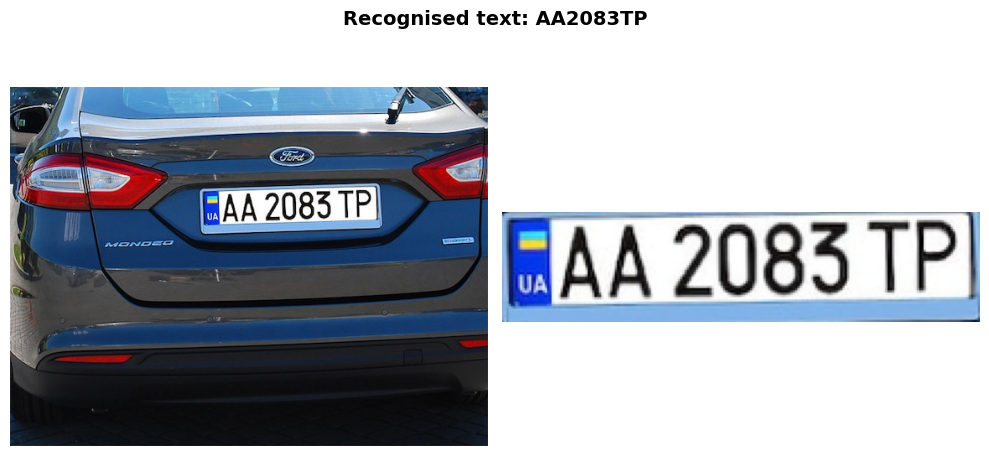

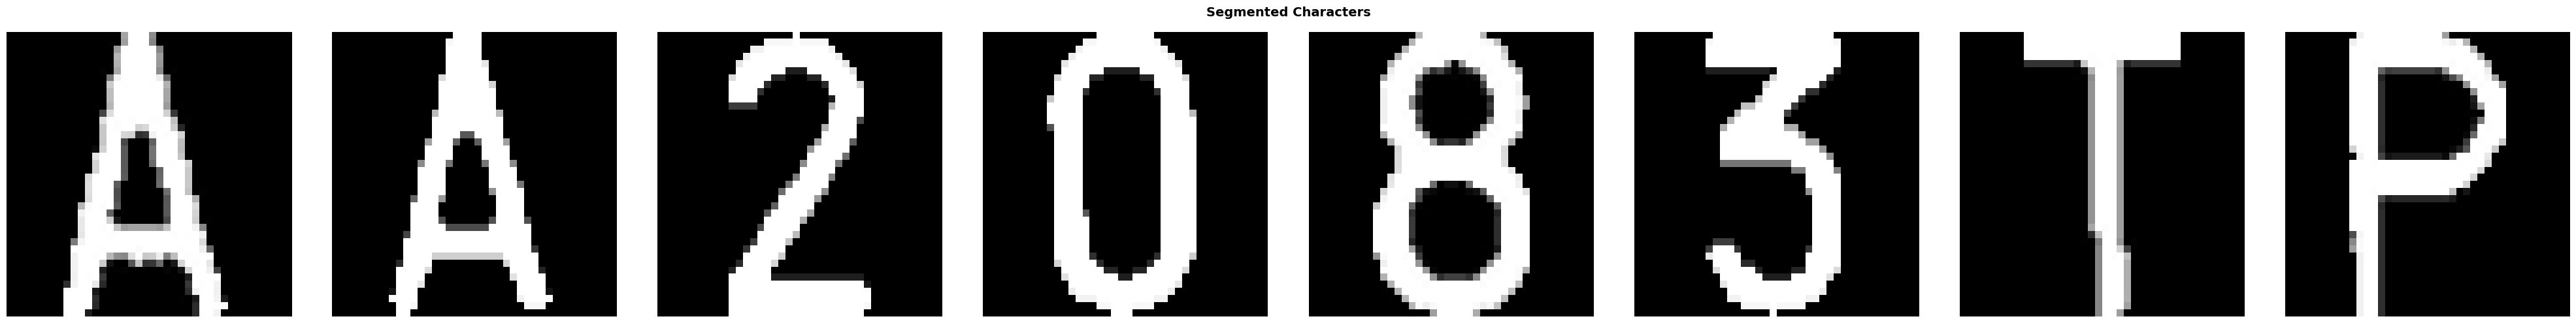

----------------------------------------


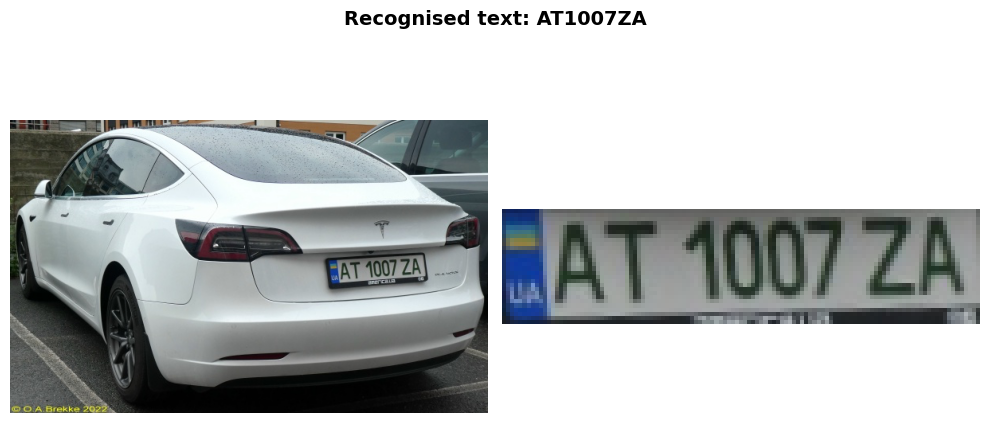

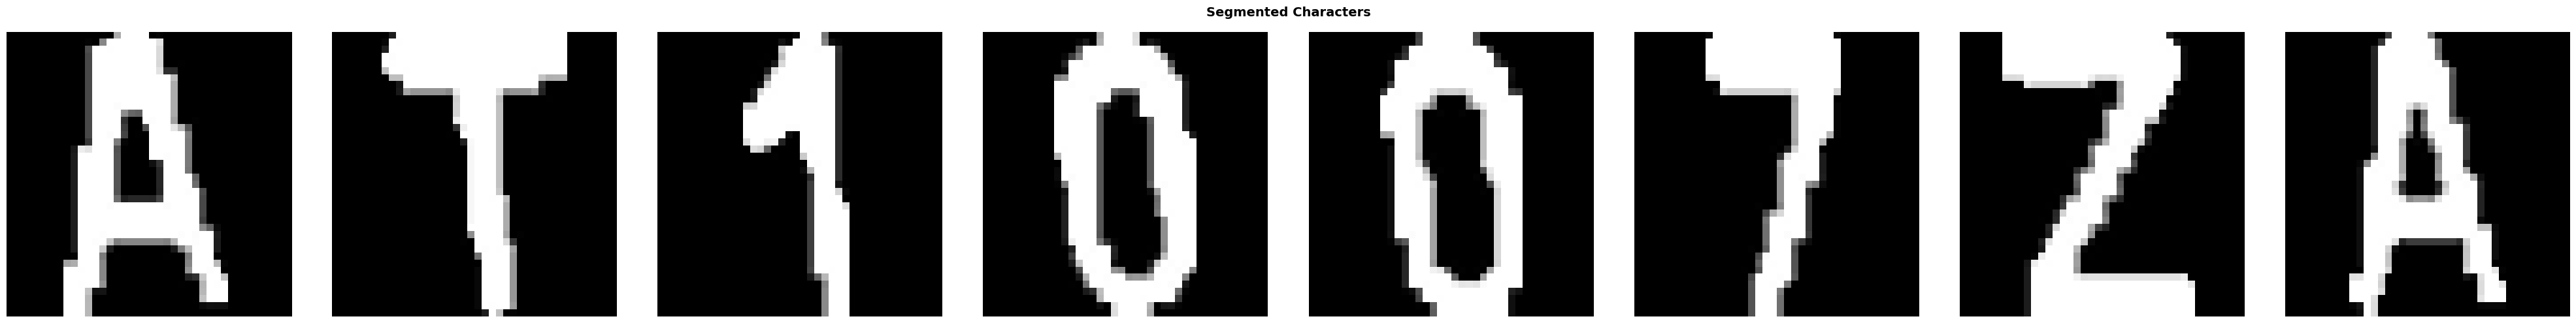

----------------------------------------


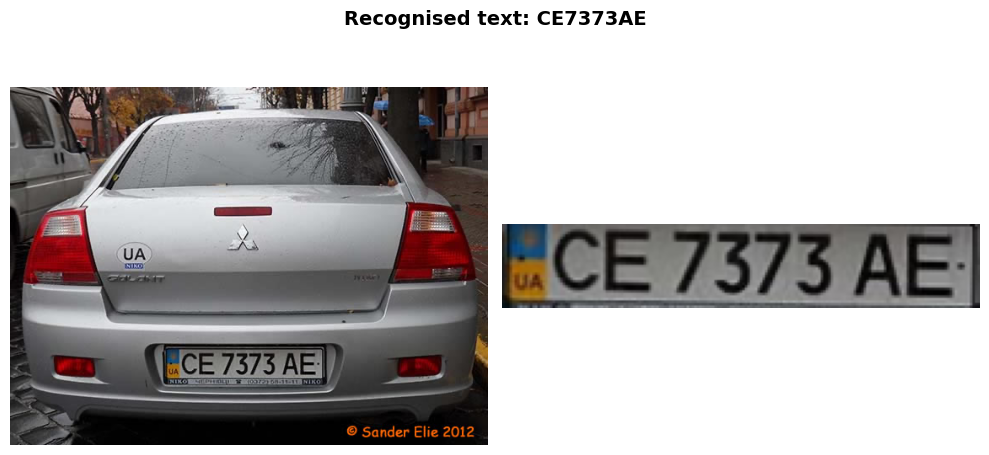

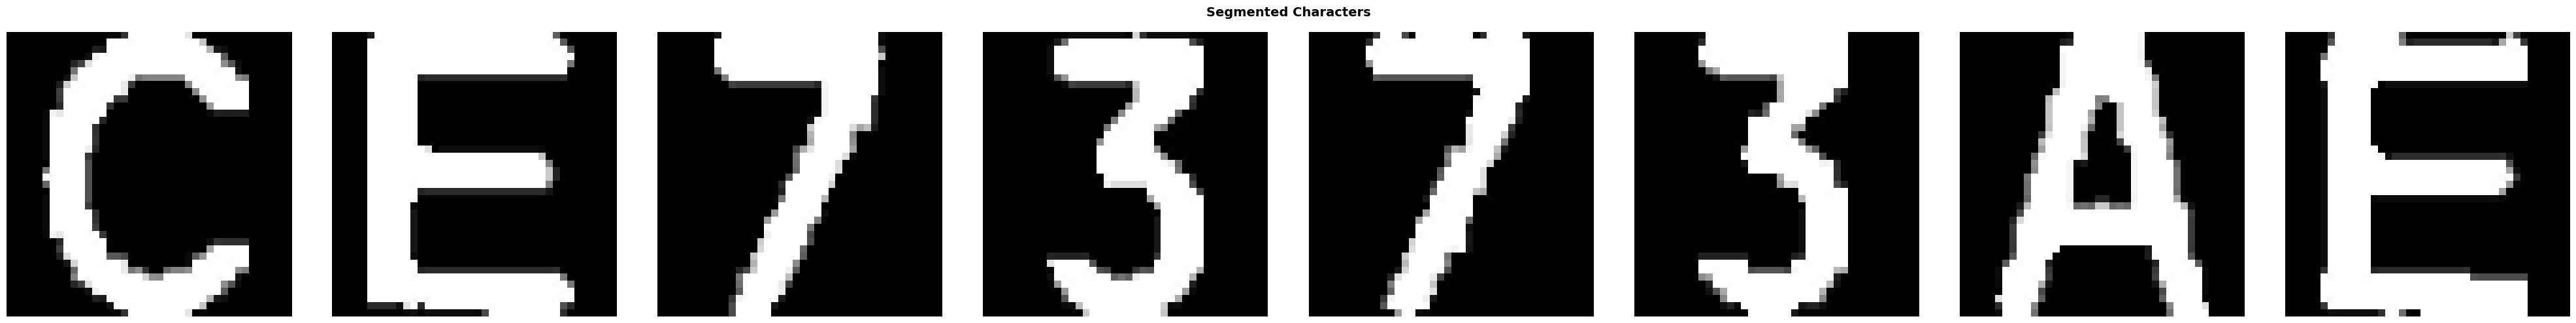

----------------------------------------


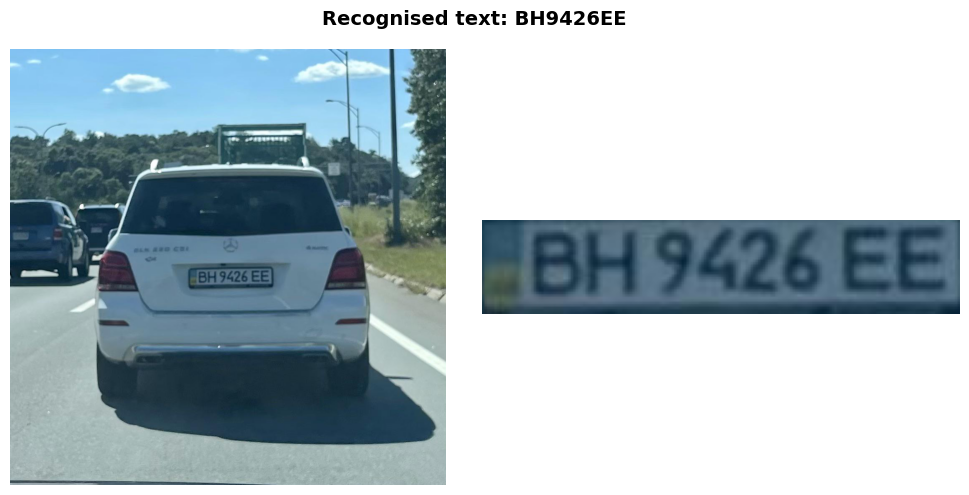

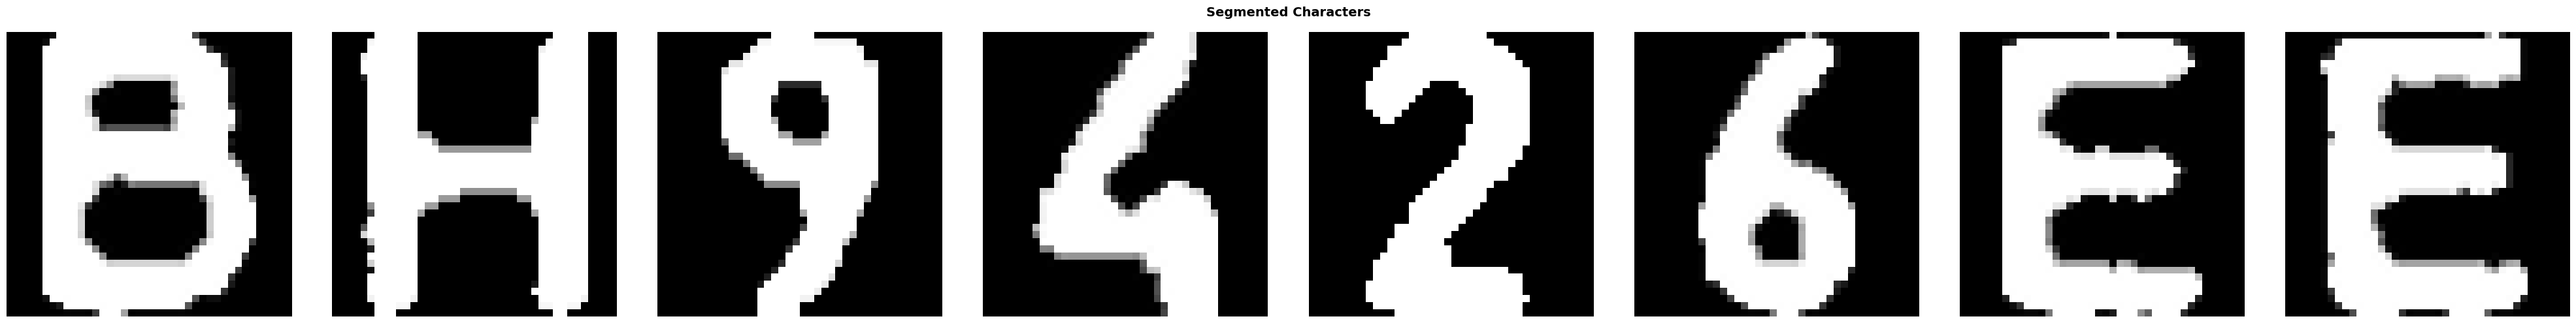

----------------------------------------


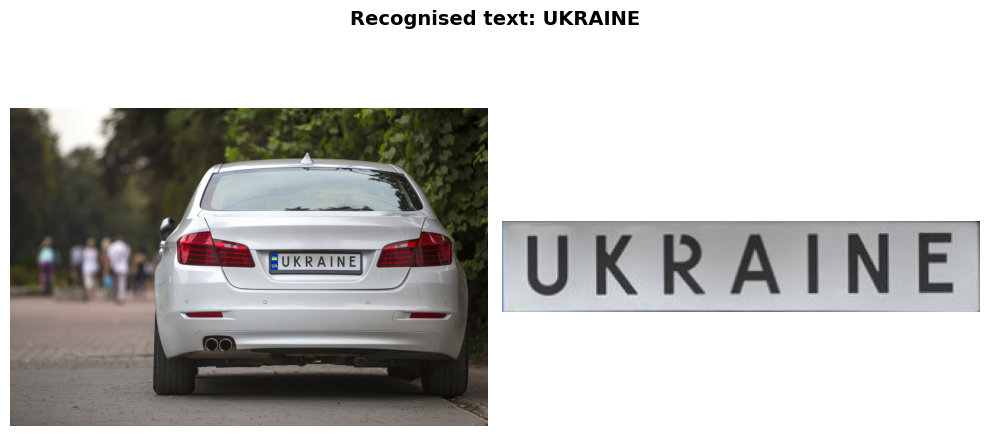

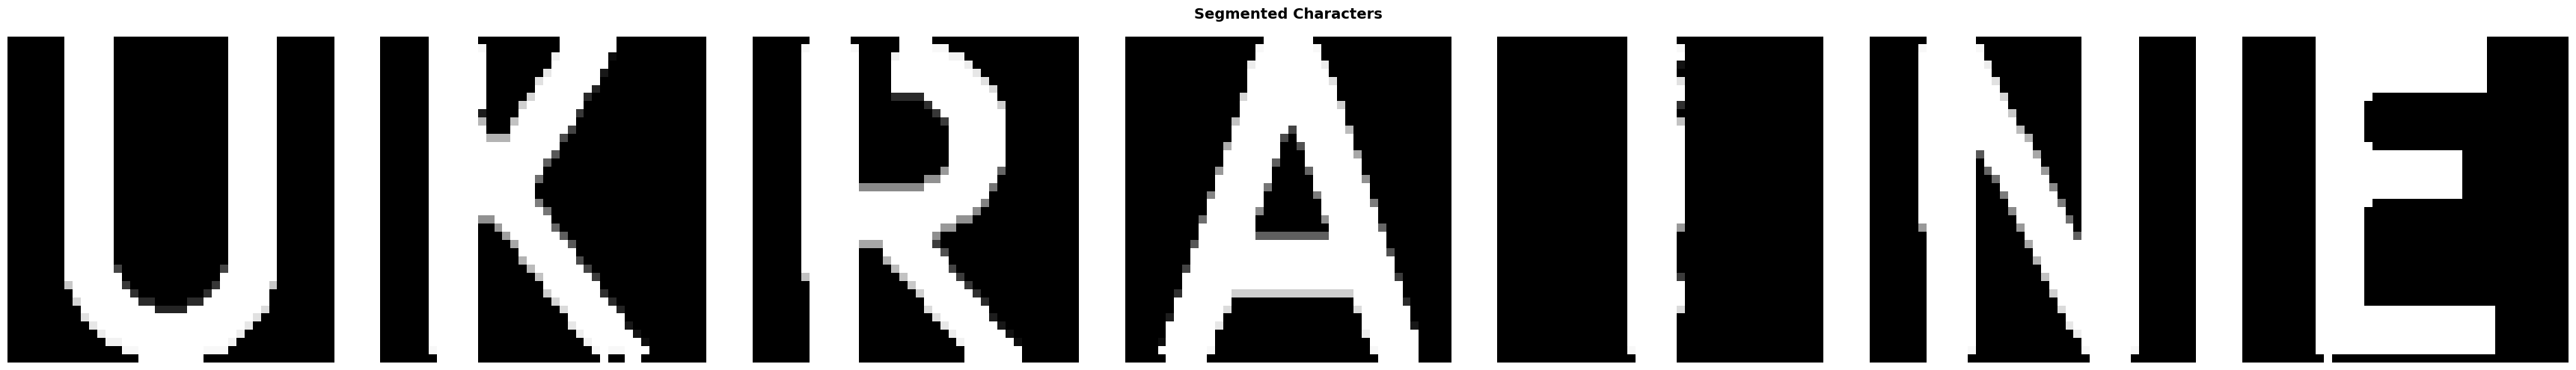

----------------------------------------


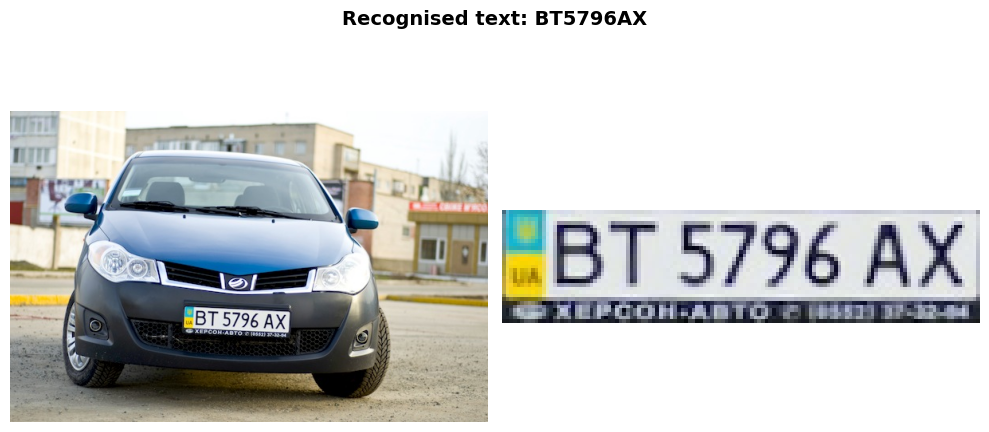

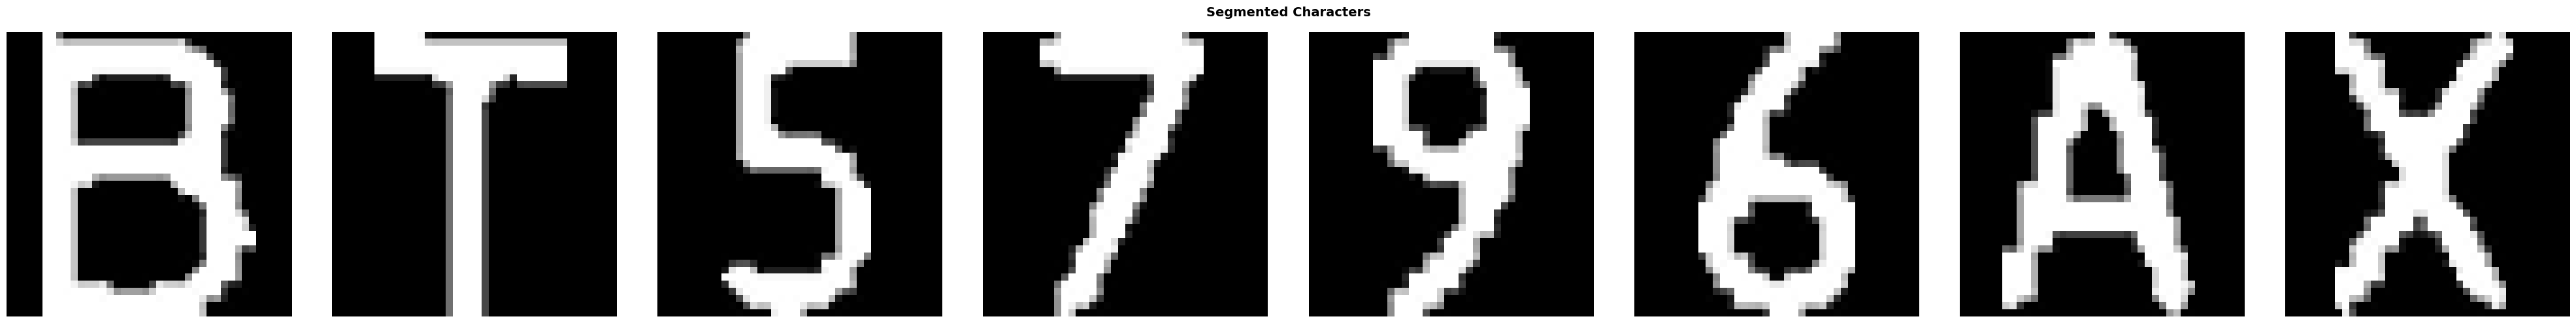

----------------------------------------


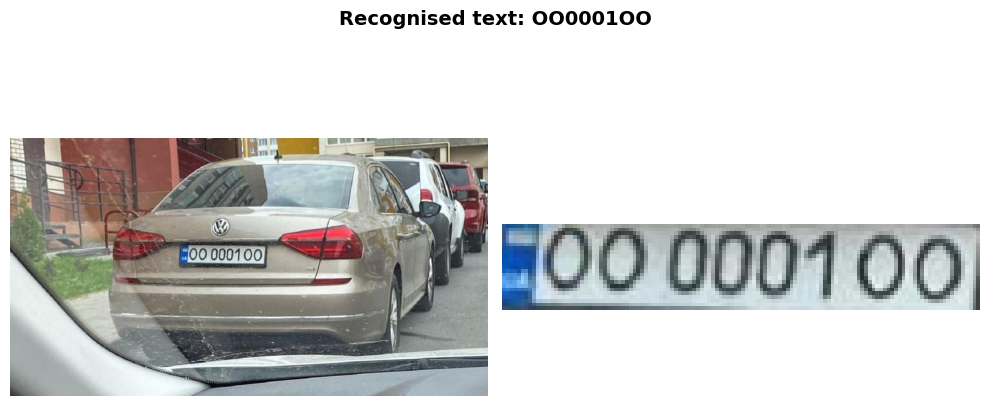

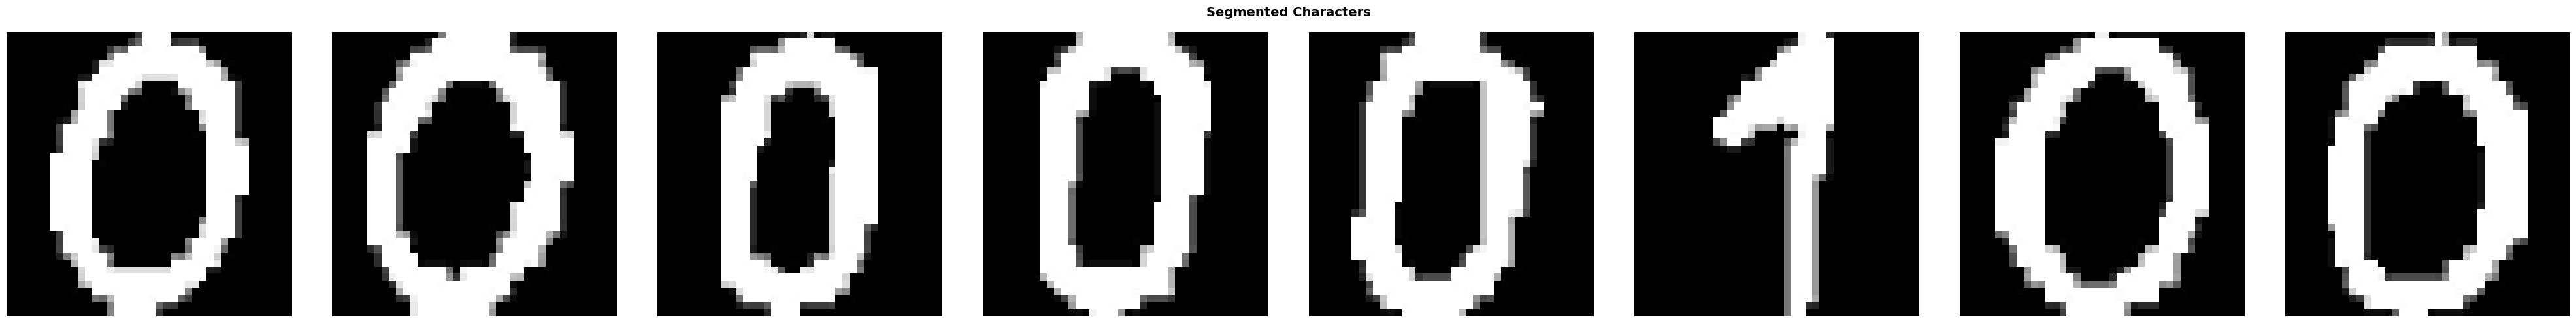

----------------------------------------


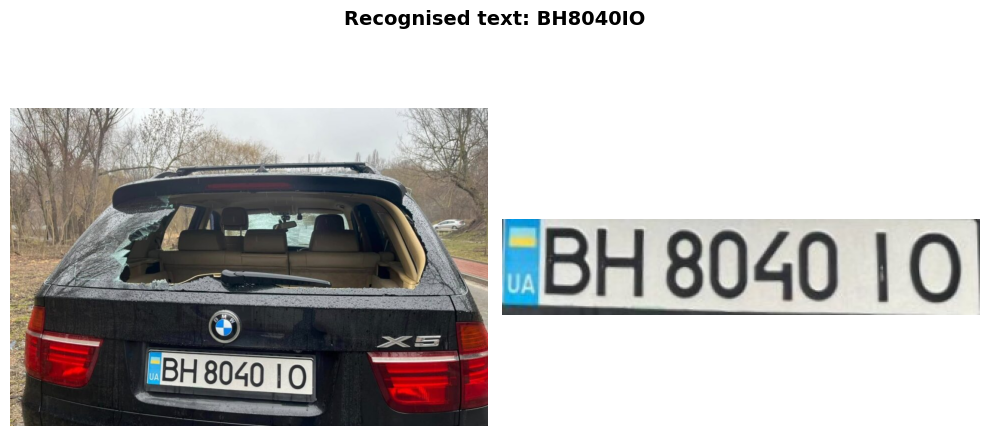

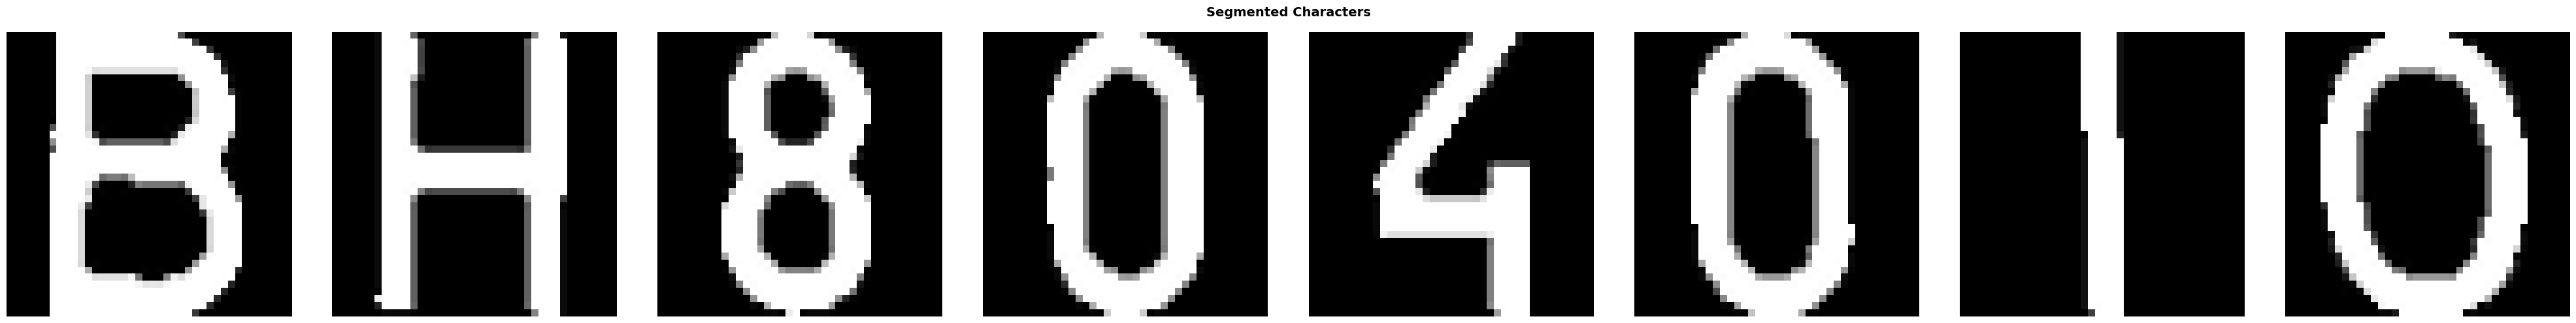

----------------------------------------


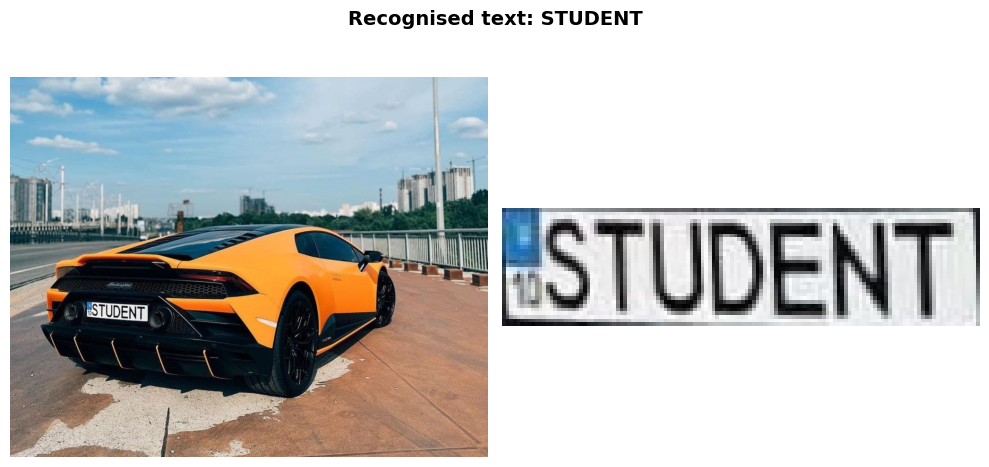

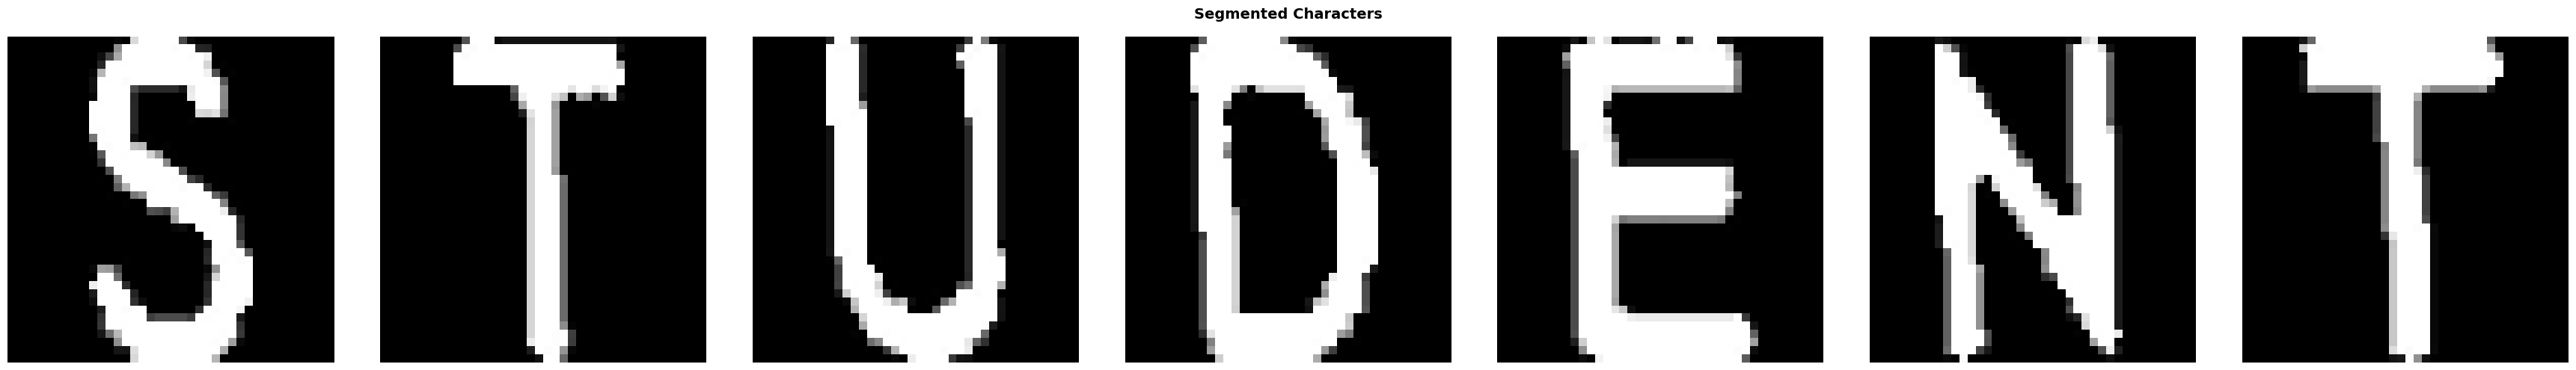

In [16]:
for image in images:
    plate, chars = find_plate(image)

    print("-" * 40)
    if plate is not None and chars is not None:
        plate_text = recognize_characters(chars, hog_descriptor, knn_model)

        show_images([image, plate], cols=2, main_title=f"Recognised text: {plate_text}")

        show_images(chars, cols=len(chars), main_title="Segmented Characters")
    else:
        show_images([image], cols=1)

---

### Improvement Ideas

**Detection Improvements:**
- Multi-scale detection for varying plate sizes
- Color-based filtering (many plates are white/yellow)
- Edge density analysis to distinguish plates from other rectangles

**Segmentation Improvements:**
- Connected component analysis with morphological operations
- Machine learning-based character/non-character classification

**Recognition Improvements:**
- More diverse training templates (additional fonts, degradations)
- Ensemble methods combining multiple classifiers
- Post-processing with dictionary/pattern validation (e.g., regional plate formats)
- Confusion pair resolution (explicit handling of O/0, I/1)

---


### Results

 This classical pipeline successfully demonstrates license plate detection and character recognition without deep learning. All license plates were recognised correctly. Even in the hardest cases like `OO 0001 OO` all characters were recognised correctly. While limited compared to modern deep learning approaches, it showcases fundamental CV techniques including edge detection, morphological operations, geometric transformations, feature extraction, and classical machine learning.
